In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import wfdb

# Set device for training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Path to the dataset folder
DATASET_PATH = "C:/Users/Asus/Desktop/surface-electromyographic-signals-collected-during-long-lasting-ground-walking-of-young-able-bodied-subjects-1.0.1/"



Using device: cuda


In [4]:
import os

# Path to dataset folder
DATASET_PATH = "C:/Users/Asus/Desktop/surface-electromyographic-signals-collected-during-long-lasting-ground-walking-of-young-able-bodied-subjects-1.0.1/"

# List all files in the dataset directory
files = os.listdir(DATASET_PATH)

# Print the files
for file in files:
    print(file)


LICENSE.txt
RECORDS
S01.dat
S01.hea
S02.dat
S02.hea
S03.dat
S03.hea
S04.dat
S04.hea
S05.dat
S05.hea
S06.dat
S06.hea
S07.dat
S07.hea
S08.dat
S08.hea
S09.dat
S09.hea
S10.dat
S10.hea
S11.dat
S11.hea
S12.dat
S12.hea
S13.dat
S13.hea
S14.dat
S14.hea
S15.dat
S15.hea
S16.dat
S16.hea
S17.dat
S17.hea
S18.dat
S18.hea
S19.dat
S19.hea
S20.dat
S20.hea
S21.dat
S21.hea
S22.dat
S22.hea
S23.dat
S23.hea
S24.dat
S24.hea
S25.dat
S25.hea
S26.dat
S26.hea
S27.dat
S27.hea
S28.dat
S28.hea
S29.dat
S29.hea
S30.dat
S30.hea
S31.dat
S31.hea
SHA256SUMS.txt
Subject_info.csv


In [1]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import wfdb
import pandas as pd

# Set device for training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Path to the dataset folder
DATASET_PATH = "C:/Users/Asus/Desktop/surface-electromyographic-signals-collected-during-long-lasting-ground-walking-of-young-able-bodied-subjects-1.0.1/"  # Update this if needed


Using device: cuda


In [2]:
def load_sEMG_data(subject_id):
    """Load sEMG signals for a given subject ID."""
    record_name = f"S{subject_id:02d}"  # e.g., "S01", "S02"
    file_path = os.path.join(DATASET_PATH, record_name)

    try:
        # Read signal
        signals, fields = wfdb.rdsamp(file_path)

        # Normalize signals
        signals = (signals - np.min(signals)) / (np.max(signals) - np.min(signals))

        return signals

    except Exception as e:
        print(f"Error reading {record_name}: {e}")
        return None

# Test loading data
sample_data = load_sEMG_data(1)
print("Sample Signal Shape:", sample_data.shape if sample_data is not None else "Error")


Sample Signal Shape: (611001, 14)


In [3]:
def segment_signal(signal, window_size=200, step_size=50):
    """
    Splits the sEMG signal into overlapping windows.
    Args:
        signal (numpy array): Shape (time_steps, channels)
        window_size (int): Number of samples per window
        step_size (int): Step size for overlapping
    Returns:
        numpy array of shape (num_windows, window_size, channels)
    """
    num_samples, num_channels = signal.shape
    segments = []
    
    for start in range(0, num_samples - window_size, step_size):
        end = start + window_size
        segments.append(signal[start:end, :])  # Extract window
    
    return np.array(segments)

# Apply segmentation
segmented_data = segment_signal(sample_data)
print("Segmented Data Shape:", segmented_data.shape)  # Expected: (num_windows, window_size, 14)


Segmented Data Shape: (12217, 200, 14)


In [4]:
import torch
from torch.utils.data import Dataset, DataLoader

class SEMGDataset(Dataset):
    def __init__(self, data, labels):
        """
        Args:
            data (numpy array): Shape (num_samples, window_size, channels)
            labels (numpy array): Shape (num_samples,)
        """
        self.data = torch.tensor(data, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

# Dummy Labels (Replace with actual subject IDs)
num_samples = segmented_data.shape[0]
labels = np.random.randint(0, 31, size=num_samples)  # Assuming 31 subjects

# Create Dataset
dataset = SEMGDataset(segmented_data, labels)
print(f"Dataset Size: {len(dataset)}")


Dataset Size: 12217


In [5]:
# Split into train & test
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Create DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [6]:
import torch.nn as nn

class CNN_LSTM_Model(nn.Module):
    def __init__(self, num_classes=31):
        super(CNN_LSTM_Model, self).__init__()
        
        # CNN Layers
        self.conv1 = nn.Conv1d(in_channels=14, out_channels=32, kernel_size=5, stride=1, padding=2)
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, stride=1, padding=2)
        self.conv3 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=5, stride=1, padding=2)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
        
        # LSTM Layers
        self.lstm = nn.LSTM(input_size=128, hidden_size=64, num_layers=2, batch_first=True, bidirectional=True)
        
        # Fully Connected Layer
        self.fc = nn.Linear(64 * 2, num_classes)  # Bidirectional LSTM (2 * hidden_size)
    
    def forward(self, x):
        x = x.permute(0, 2, 1)  # Change shape to (batch, channels, time)
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        
        x = x.permute(0, 2, 1)  # Change shape back to (batch, time, features)
        x, _ = self.lstm(x)  # LSTM output
        x = x[:, -1, :]  # Take last time-step output
        
        x = self.fc(x)  # Fully connected layer
        return x

# Model instance
model = CNN_LSTM_Model(num_classes=31).to(device)
print(model)


CNN_LSTM_Model(
  (conv1): Conv1d(14, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (conv2): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (conv3): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
  (relu): ReLU()
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (lstm): LSTM(128, 64, num_layers=2, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=128, out_features=31, bias=True)
)


In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [8]:
def train(model, train_loader, criterion, optimizer, num_epochs=10):
    model.train()
    for epoch in range(num_epochs):
        total_loss = 0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(train_loader):.4f}")

# Train the model
train(model, train_loader, criterion, optimizer, num_epochs=10)


Epoch [1/10], Loss: 3.4359
Epoch [2/10], Loss: 3.4346
Epoch [3/10], Loss: 3.4341
Epoch [4/10], Loss: 3.4340
Epoch [5/10], Loss: 3.4340
Epoch [6/10], Loss: 3.4339
Epoch [7/10], Loss: 3.4337
Epoch [8/10], Loss: 3.4336
Epoch [9/10], Loss: 3.4337
Epoch [10/10], Loss: 3.4336


In [11]:
def evaluate(model, test_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    print(f"Test Accuracy: {correct*10/total:.4f}")

# Evaluate
evaluate(model, test_loader)


Test Accuracy: 0.3846


In [2]:
import pandas as pd

df = pd.read_csv('Subject_info.csv')
print(df.columns)


Index(['N.;Signal name;Gender;Age (years);Height (cm);Weight (Kg)'], dtype='object')


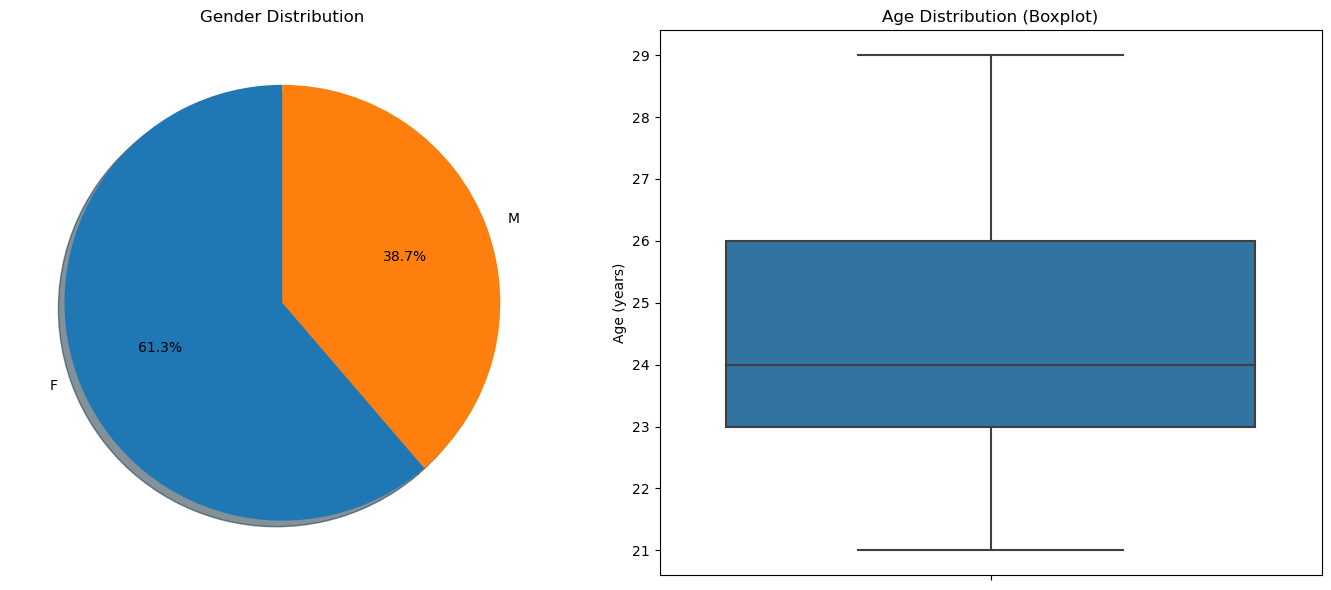

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load with correct separator
df = pd.read_csv('Subject_info.csv', sep=';')

# Create the subplot layout
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Pie Chart: Gender Distribution ---
df['Gender'].value_counts().plot.pie(
    autopct='%1.1f%%', startangle=90, shadow=True, ax=axes[0])
axes[0].set_title("Gender Distribution")
axes[0].set_ylabel('')

# --- Boxplot: Age ---
sns.boxplot(y=df['Age (years)'], ax=axes[1])
axes[1].set_title("Age Distribution (Boxplot)")
axes[1].set_ylabel("Age (years)")

plt.tight_layout()
plt.show()
